In [18]:
import os, sys
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import dump_io as io

import pickle as pk
from astropy import constants as const, units as u

%matplotlib inline


In [19]:
dirc = 'out/'

def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]
def load3D(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer]

snap = 1000

In [20]:
dmp = io.readDump(f'{dirc}/dump.0000.dmp')
r, th, phi = dmp.x1, dmp.x2, dmp.x3


uL = 1e8 *u.cm.cgs
uM = 1e24*u.g.cgs
uv = 1e5*u.cm.cgs/u.s.cgs
uT = ((u.g.cgs/u.mol.cgs) * uv**2 / (const.k_B.cgs * const.N_A.cgs)).decompose()
ud = uM/uL**3

mu = 30

u_aR = (uM*uv**2/(uL**3 * uT**4)).decompose()
aR = ((4*const.sigma_sb/const.c)/u_aR ).to_value()

sig = 0.25*aR*3e5


In [21]:
def plot_gd_map(x, z, qty_gas, qty_dust, label, fax=None, norm=None, units=1):
    if fax is None:
        fig, ax = plt.subplots(1,1, figsize=(6,5))
    else:
        fig, ax = fax

    if norm is None:
        q_max = max(qty_gas.max(), qty_dust.max())
        q_min = min(qty_gas.min(), qty_dust.min())

        norm = LogNorm(vmin=max(q_min, 1e-8*q_max))

    im = ax.pcolormesh(-x, z, qty_gas * units, norm=norm)
    im2 = ax.pcolormesh(x, z, qty_dust * units, norm=norm)

    ax.axvline(0, color='k', lw=0.5)

    zmax = np.max(z)
    xmax = np.max(x)
    ax.text(-0.95*xmax, 0.95*zmax, 'Gas', fontsize=12, ha='left', va='top')
    ax.text(0.95*xmax, 0.95*zmax, 'Dust', fontsize=12, ha='right', va='top')

    ax.set_xlabel('Radius [1000km]')
    ax.set_ylabel('Z [1000km]')
    fig.colorbar(im, ax=ax, label=label)

    return fig, ax



(<Figure size 600x500 with 2 Axes>,
 <Axes: xlabel='Radius [1000km]', ylabel='Z [1000km]'>)

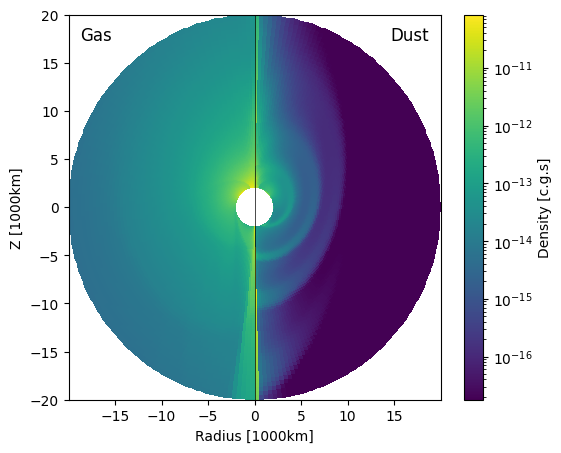

In [22]:
rho = load(i=snap, var='Vc-RHO')
rho_d = load(i=snap, var='Dust0_Vc-RHO')

z = r*np.cos(th[:,None])
x = r*np.sin(th[:,None])

plot_gd_map(x, z, rho, rho_d, label='Density [c.g.s]')

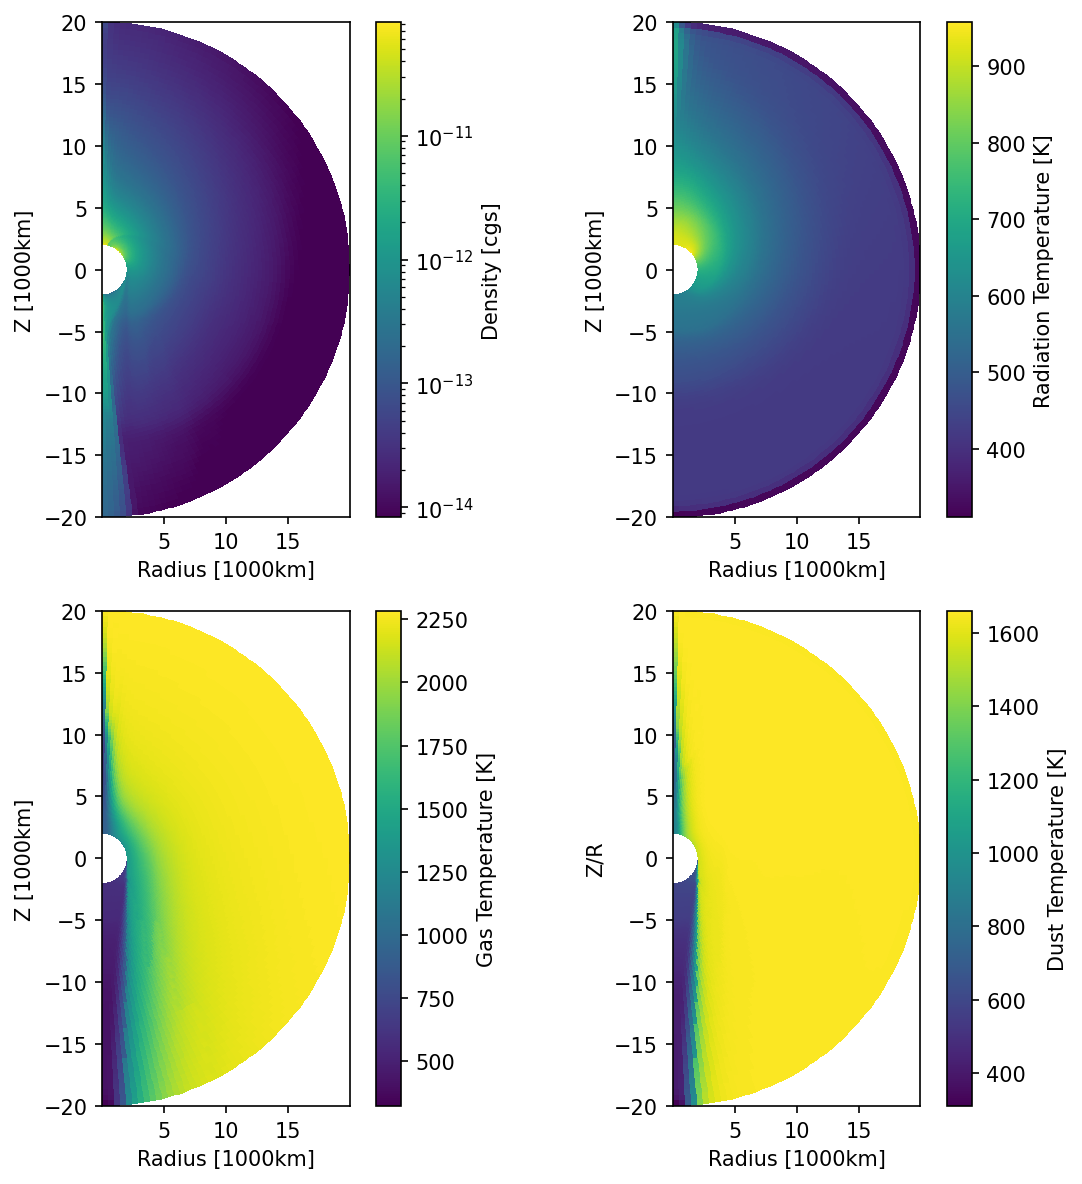

In [23]:
fig, ax = plt.subplots(2, 2, dpi=150, figsize=(8,8))
ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')



rho = load(i=snap, var='Vc-RHO')
P = load(i=snap, var='Vc-PRS')
Er = load(i=snap, var='ERAD')

Tr = (Er/aR)**0.25 

T = mu * (P/rho)

z = r*np.cos(th[:,None])
x = r*np.sin(th[:,None])

im = ax[0,0].pcolormesh(x, z, rho * ud.to_value('g/cm**3'), norm=LogNorm(vmin=1e-4*rho.max() *ud.to_value('g/cm**3')))
ax[0,0].set_xlabel('Radius [1000km]')
ax[0,0].set_ylabel('Z [1000km]')
fig.colorbar(im, ax=ax[0,0], label='Density [cgs]')

im = ax[0,1].pcolormesh(x, z, Tr * uT.to_value('K'))
ax[0,1].set_xlabel('Radius [1000km]')
ax[0,1].set_ylabel('Z [1000km]')
fig.colorbar(im, ax=ax[0,1], label='Radiation Temperature [K]')

im = ax[1,0].pcolormesh(x, z, T * uT.to_value('K'))
ax[1,0].set_xlabel('Radius [1000km]')
ax[1,0].set_ylabel('Z [1000km]')
fig.colorbar(im, ax=ax[1,0], label='Gas Temperature [K]')


try:
    rho_d = load(i=snap, var='Dust0_Vc-RHO')
    T_d = load(i=snap, var='Dust0_Vc-TR0')
    im = ax[1,1].pcolormesh(x, z, T_d * uT.to_value('K'))
    ax[1,1].set_xlabel('Radius [1000km]')
    ax[1,1].set_ylabel('Z/R')
    fig.colorbar(im, ax=ax[1,1], label='Dust Temperature [K]')
except KeyError:
    pass
fig.tight_layout()


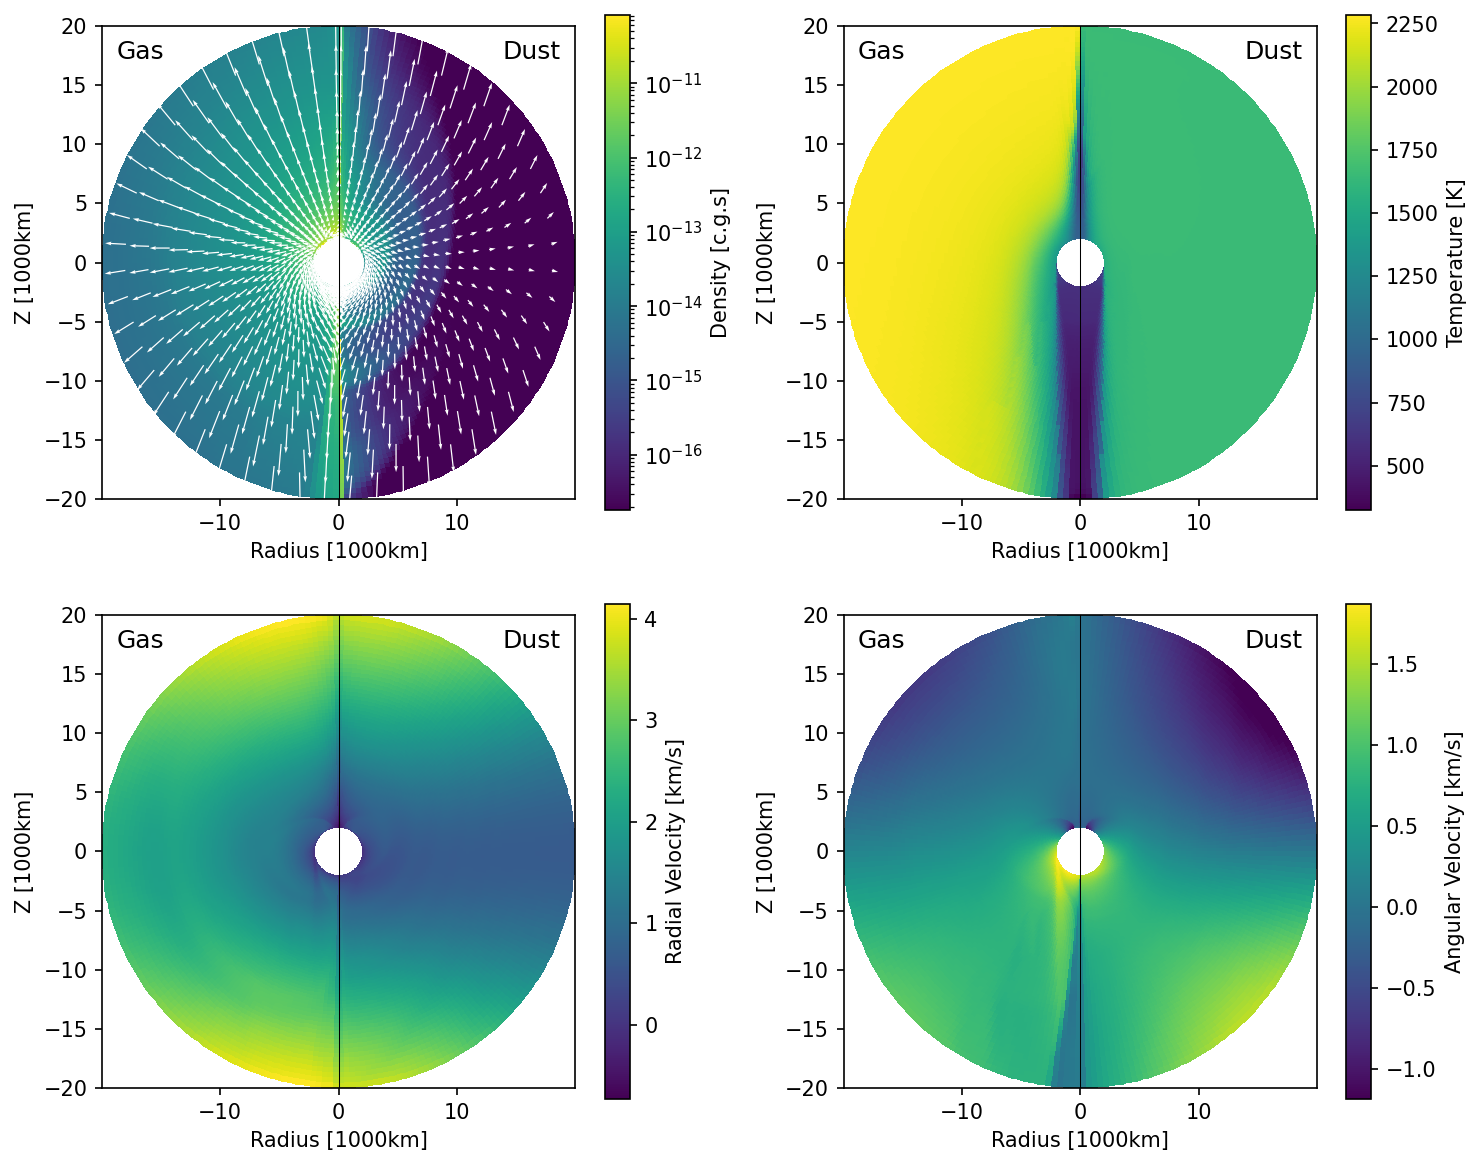

In [24]:
fig, ax = plt.subplots(2, 2, dpi=150, figsize=(10,8))
ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')

vr = load(i=snap, var='Vc-VX1')
vth = load(i=snap, var='Vc-VX2')

vz = vr * np.cos(th[:,None]) - vth * np.sin(th[:,None])
vx = vr * np.sin(th[:,None]) + vth * np.cos(th[:,None])


vr_d = load(i=snap, var='Dust0_Vc-VX1')
vth_d = load(i=snap, var='Dust0_Vc-VX2')

vz_d = vr_d * np.cos(th[:,None]) - vth_d * np.sin(th[:,None])
vx_d = vr_d * np.sin(th[:,None]) + vth_d * np.cos(th[:,None])

plot_gd_map(x, z, rho, rho_d, label='Density [c.g.s]', fax=(fig, ax[0,0]))
ax[0,0].quiver(-x[::5,::5], z[::5,::5], -vx[::5,::5], vz[::5,::5], color='white', scale=50)
ax[0,0].quiver(x[::5,::5], z[::5,::5], vx_d[::5,::5], vz_d[::5,::5], color='white', scale=50)

plot_gd_map(x, z, T, T_d, label='Temperature [K]', fax=(fig, ax[0,1]), norm=Normalize(), units=uT.to_value('K'))
plot_gd_map(x, z, vr, vr_d, label='Radial Velocity [km/s]', fax=(fig, ax[1,0]), norm=Normalize())
plot_gd_map(x, z, vth, vth_d, label='Angular Velocity [km/s]', fax=(fig, ax[1,1]), norm=Normalize())

fig.tight_layout()


Maximum surface temperature: 1857.8109866384764
Maximum Dust temperature: 2283.9406964038503


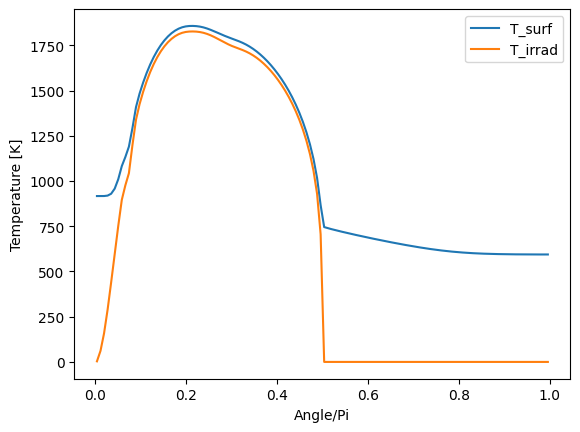

In [25]:
surf = np.genfromtxt(f'out/surface_{snap}.txt').reshape(-1, th.shape[0], 4)
print('Maximum surface temperature:', surf[:,:,2].max() * uT.to_value('K'))
print('Maximum Dust temperature:', T.max() * uT.to_value('K'))

plt.plot(th/np.pi, surf[0,:,2] * uT.to_value('K'), label='T_surf')
plt.plot(th/np.pi, (-surf[0,:,3]/sig)**0.25 * uT.to_value('K'), label='T_irrad')
plt.xlabel('Angle/Pi')
plt.ylabel('Temperature [K]')
plt.legend()

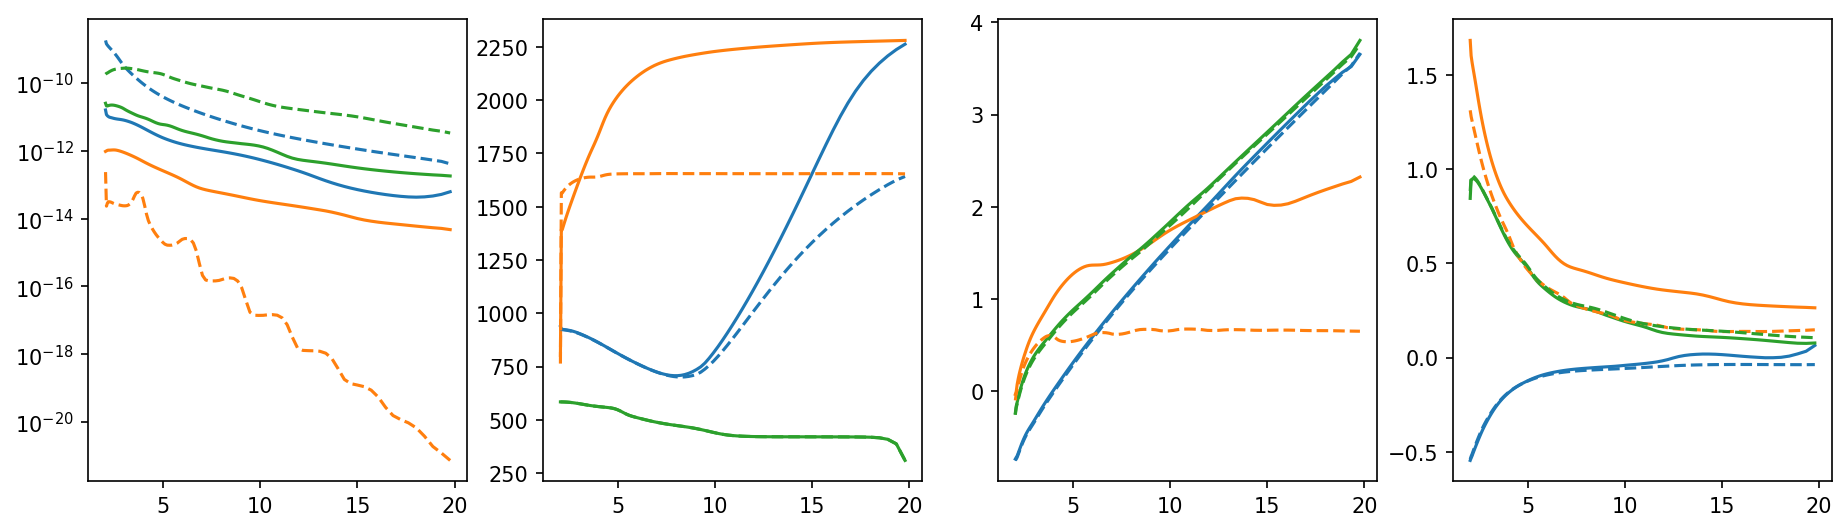

In [26]:
fig, ax = plt.subplots(1, 4, dpi=150, figsize=(15,4))
ax[0].plot(r, rho[0])
ax[0].plot(r, rho[65])
ax[0].semilogy(r, rho[-1])

ax[0].plot(r, rho_d[0], ls='--',  c='C0')
ax[0].plot(r, rho_d[65], ls='--',  c='C1')
ax[0].semilogy(r, rho_d[-1], ls='--',  c='C2')


ax[1].plot(r, T[0] * uT.to_value('K'))
ax[1].plot(r, T[65] * uT.to_value('K'))
ax[1].plot(r, T_d[-1] * uT.to_value('K'))

ax[1].plot(r, T_d[0] * uT.to_value('K'), ls='--',  c='C0')
ax[1].plot(r, T_d[65] * uT.to_value('K'), ls='--',  c='C1')
ax[1].plot(r, T_d[-1] * uT.to_value('K'), ls='--',  c='C2')

ax[2].plot(r, vr[0])
ax[2].plot(r, vr[65])
ax[2].plot(r, vr[-1])

ax[2].plot(r, vr_d[0], ls='--',  c='C0')
ax[2].plot(r, vr_d[65], ls='--',  c='C1')
ax[2].plot(r, vr_d[-1], ls='--',  c='C2')


ax[3].plot(r, vth[0])
ax[3].plot(r, vth[65])
ax[3].plot(r, vth[-1])
ax[3].plot(r, vth_d[0], ls='--',  c='C0')
ax[3].plot(r, vth_d[65],  ls='--', c='C1')
ax[3].plot(r, vth_d[-1], ls='--', c='C2')

In [28]:
for i in range(1000):
    dmp = io.readDump(f'{dirc}/dump.{i:04d}.dmp')
    rho = dmp.data['Vc-RHO'].transpose(2,1,0)[0]
    rho_d = dmp.data['Dust0_Vc-RHO'].transpose(2,1,0)[0]
    f, ax = plot_gd_map(x, z, rho, rho_d, label='Density [c.g.s]', norm=LogNorm(vmin=1e-17, vmax=1e-10))
    f.savefig(f'frames/frame_{i:04d}.png')
    plt.close(f)